In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [13]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

fund = pd.read_csv("../data/processed/fund_master_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_cleaned.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

In [14]:
nav["date"]=pd.to_datetime(nav["date"])

aum["date"]=pd.to_datetime(aum["date"])

sip["month"]=pd.to_datetime(sip["month"])

category["month"]=pd.to_datetime(category["month"])

folio["month"]=pd.to_datetime(folio["month"])

transactions["transaction_date"]=pd.to_datetime(transactions["transaction_date"])

Chart 1 NAV Trend

In [15]:
nav_plot=nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code"
)
fig=px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()

fig.write_image("../charts/nav_trend.png")

Daily NAVs across most schemes exhibited a sustained upward trend during 2023, indicating a broad-based bull market. A temporary decline was observed during 2024 across several funds, corresponding to a market-wide correction.

Chart 2 AUM Growth

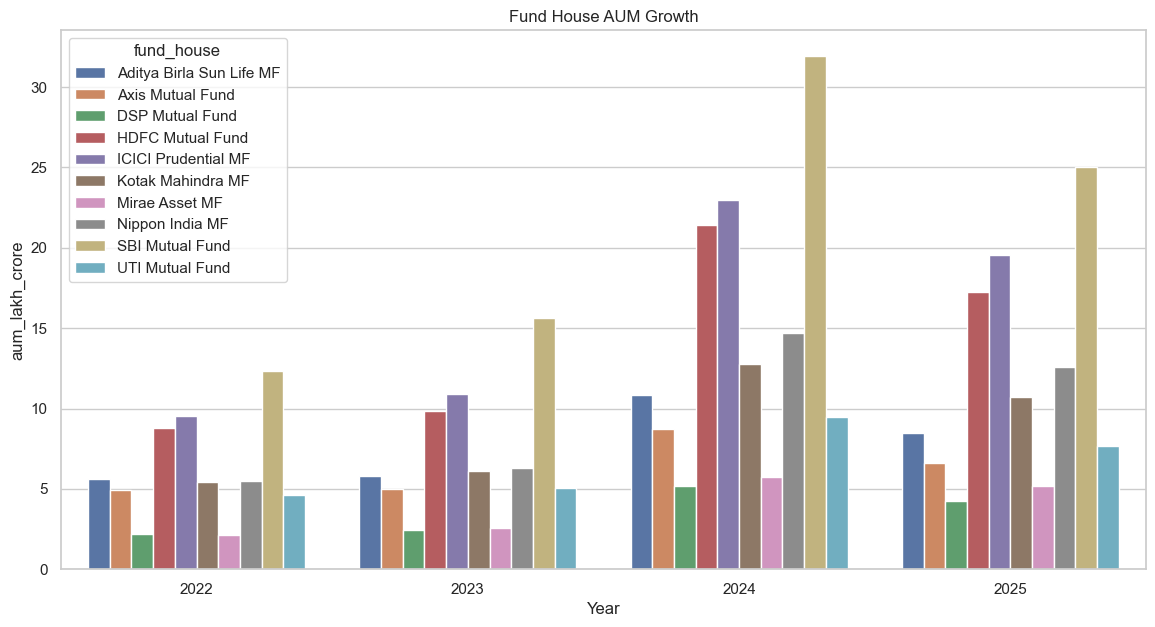

In [16]:
aum["Year"]=aum["date"].dt.year

pivot=(
    aum.groupby(
        ["Year","fund_house"]
    )["aum_lakh_crore"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(14,7))

sns.barplot(
    data=pivot,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Fund House AUM Growth")

plt.savefig("../charts/aum_growth.png")

plt.show()

SBI Mutual Fund consistently maintained the highest Assets Under Management throughout 2022–2025.

Chart 3 Monthly SIP Trend

In [17]:
fig=px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr"
)

fig.show()

fig.write_image("../charts/sip_trend.png")

Monthly SIP inflows increased steadily and reached an all-time high of ₹31,002 crore in December 2025.

Chart 4 Category Heatmap

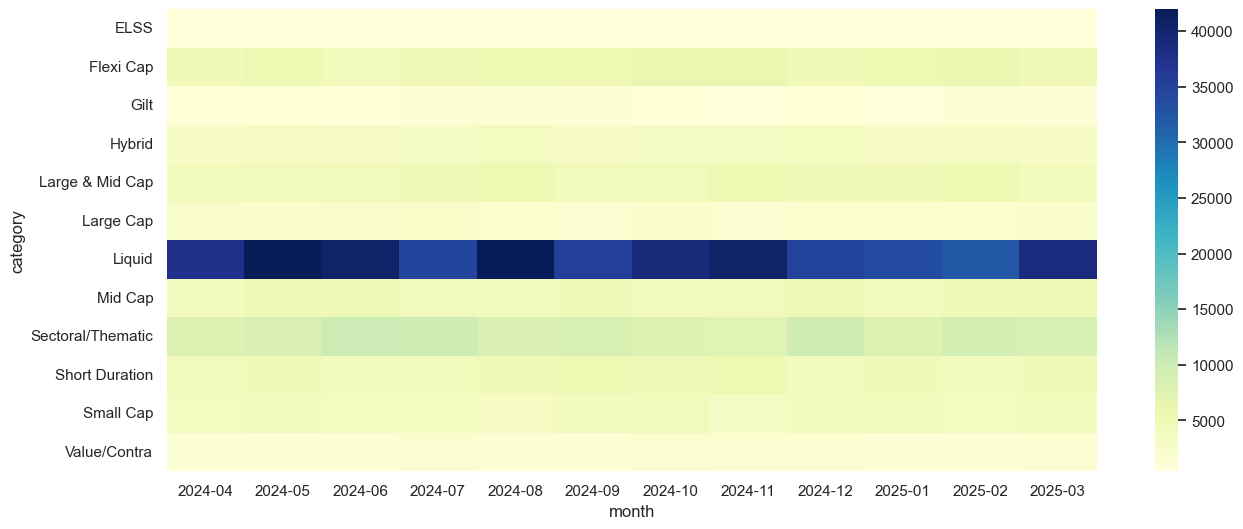

In [18]:
heat=category.pivot_table(
    index="category",
    columns=category["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    heat,
    cmap="YlGnBu"
)

plt.savefig("../charts/category_heatmap.png")

plt.show()

Equity categories attracted stronger inflows than debt and hybrid funds during most months.

Chart 5 Age Distribution

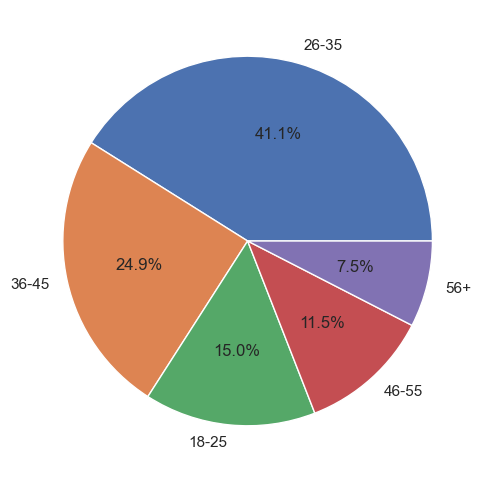

In [19]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.savefig("../charts/age_pie.png")

plt.show()

The 26–35 age group contributed the largest share of investors.

Chart 6 SIP Box Plot

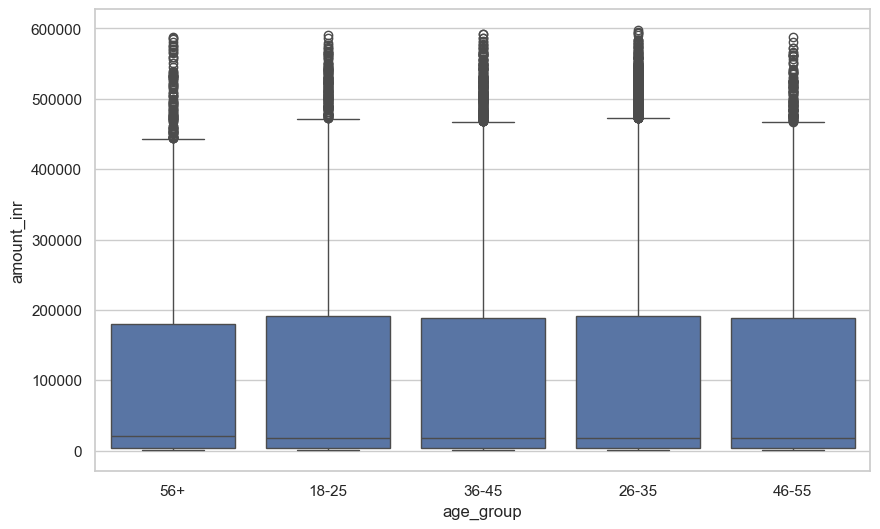

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.savefig("../charts/sip_boxplot.png")

plt.show()

Median SIP investments were highest among investors aged 36–45 years.

Chart 7 Gender Split

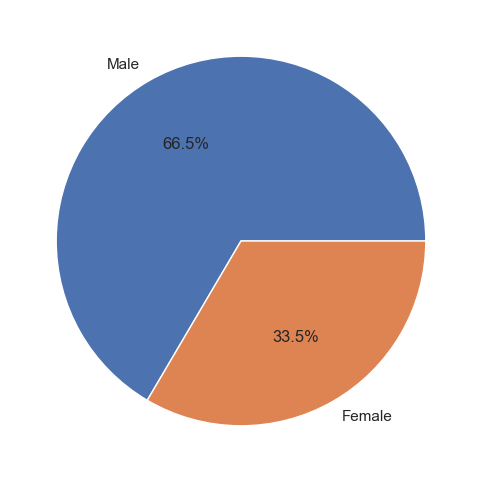

In [21]:
transactions["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.savefig("../charts/gender_split.png")

plt.show()

Male investors constituted a larger proportion of the investor base than female investors.

Chart 8 SIP by State

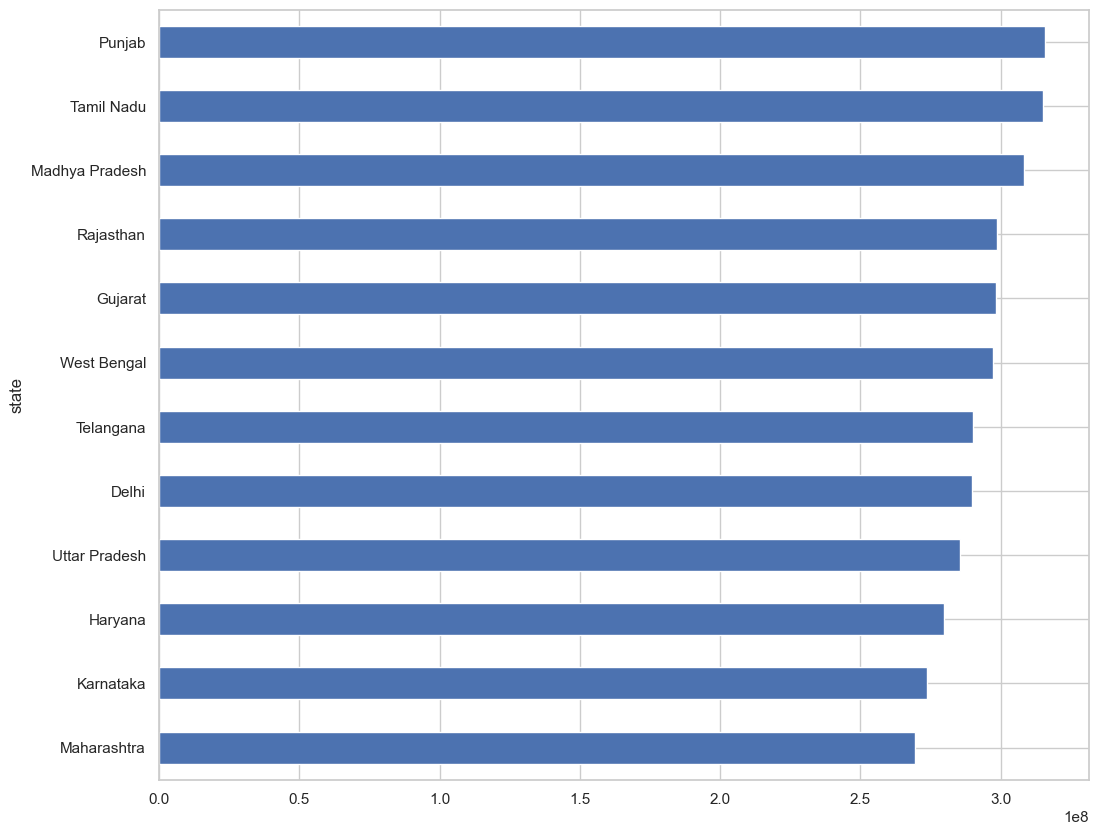

In [22]:
state=transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()
plt.figure(figsize=(12,10))

state.plot.barh()

plt.savefig("../charts/state_bar.png")

plt.show()

Maharashtra and Karnataka recorded the highest SIP contribution amounts among all states.

Chart 9 T30 vs B30

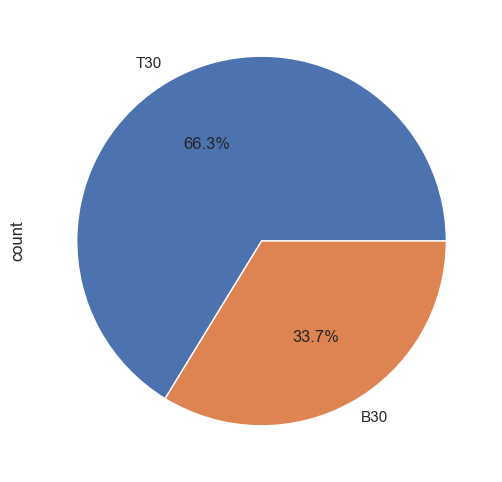

In [23]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.savefig("../charts/t30_b30.png")

plt.show()

Chart 10 Folio Growth

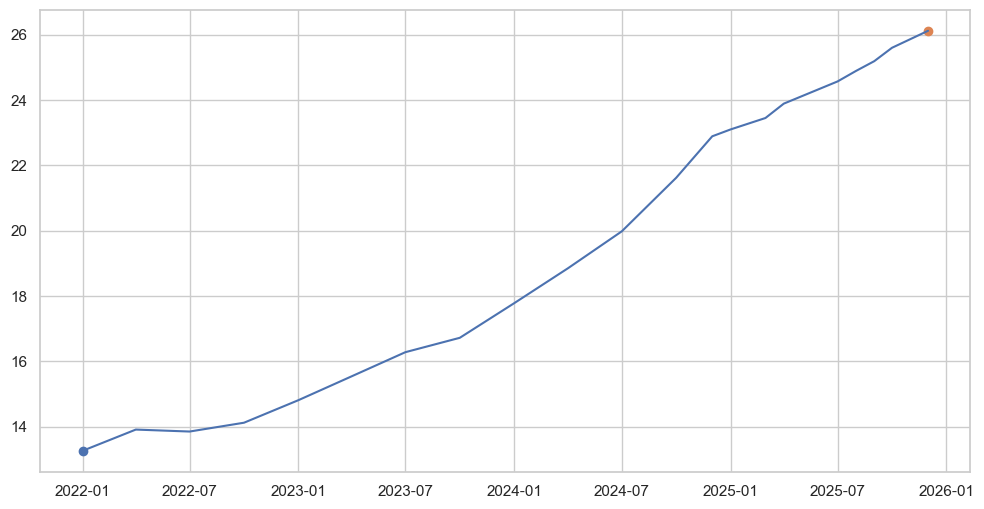

In [24]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.scatter(
    folio.iloc[0]["month"],
    13.26
)

plt.scatter(
    folio.iloc[-1]["month"],
    26.12
)

plt.savefig("../charts/folio_growth.png")

plt.show()

Chart 11 Correlation Matrix

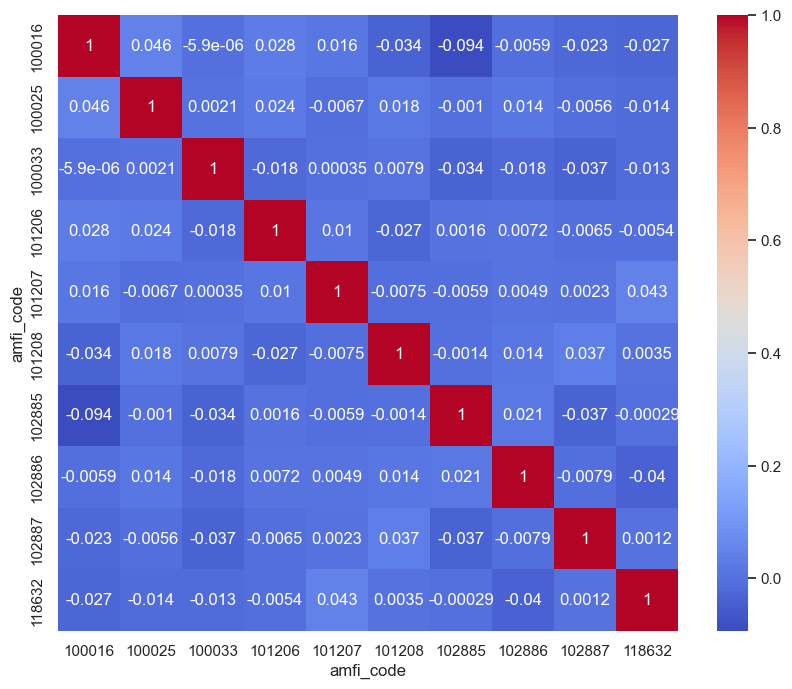

In [25]:
sample=nav[
    nav.amfi_code.isin(
        nav.amfi_code.unique()[:10]
    )
]
pivot=sample.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns=pivot.pct_change()

corr=returns.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.savefig("../charts/correlation.png")

plt.show()

Chart 12 Sector Allocation

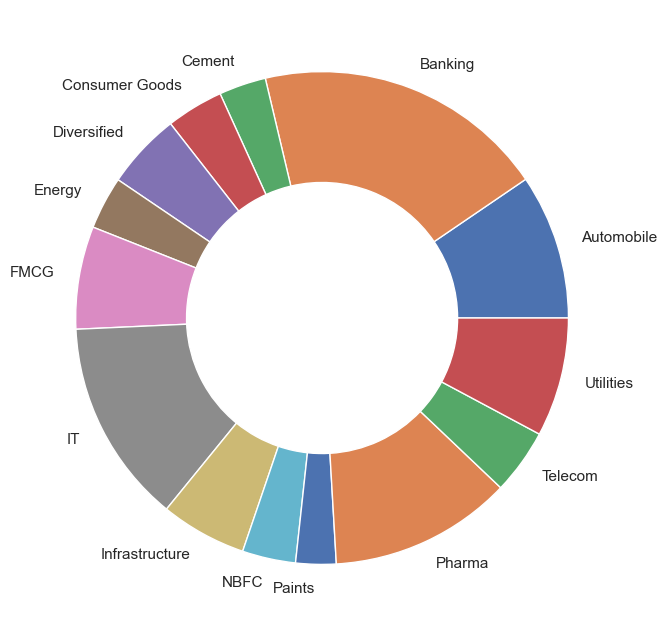

In [26]:
sector=portfolio.groupby(
    "sector"
)["weight_pct"].sum()
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.45)
)

plt.savefig("../charts/sector_donut.png")

plt.show()

Financial Services and Information Technology represented the largest sector allocations in equity fund portfolios.

Chart 13 Top 10 Funds by AUM

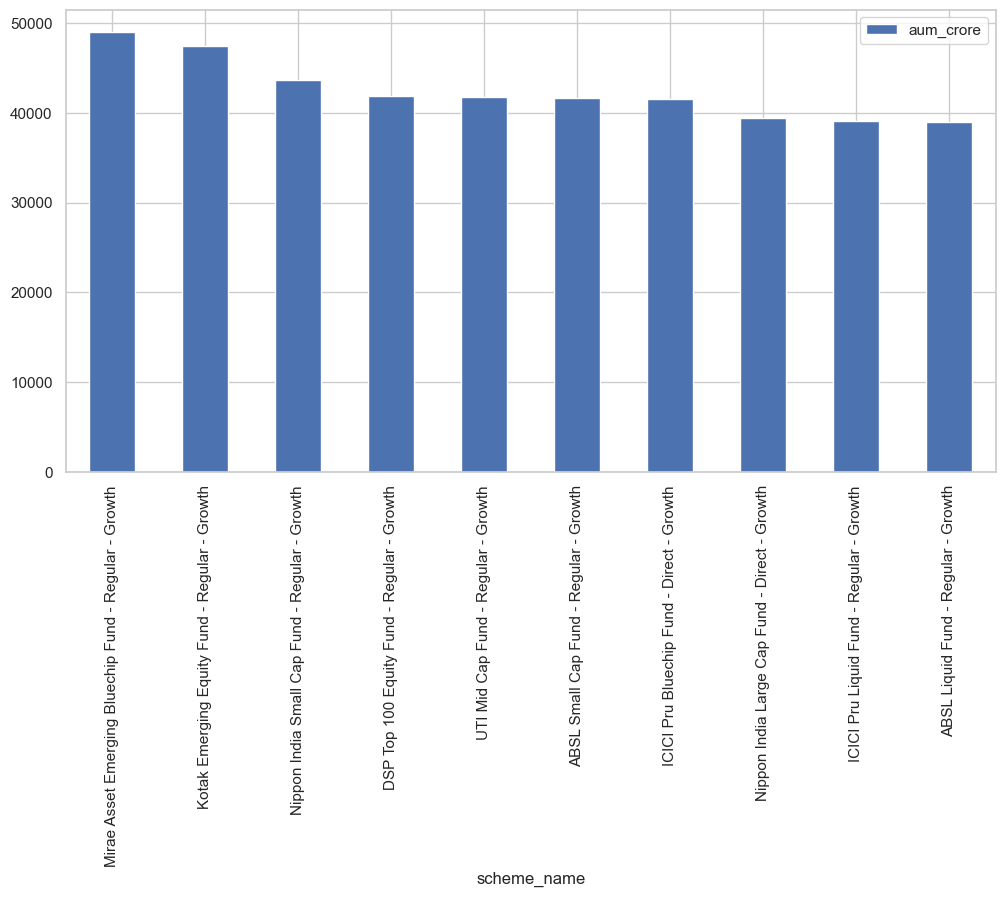

In [30]:
performance.nlargest(
10,
'aum_crore'
).plot.bar(
x='scheme_name',
y='aum_crore'
)
plt.savefig("../charts/top_10_funds_by_AUM.png")

plt.show()

Chart 14 Expense Ratio Distribution

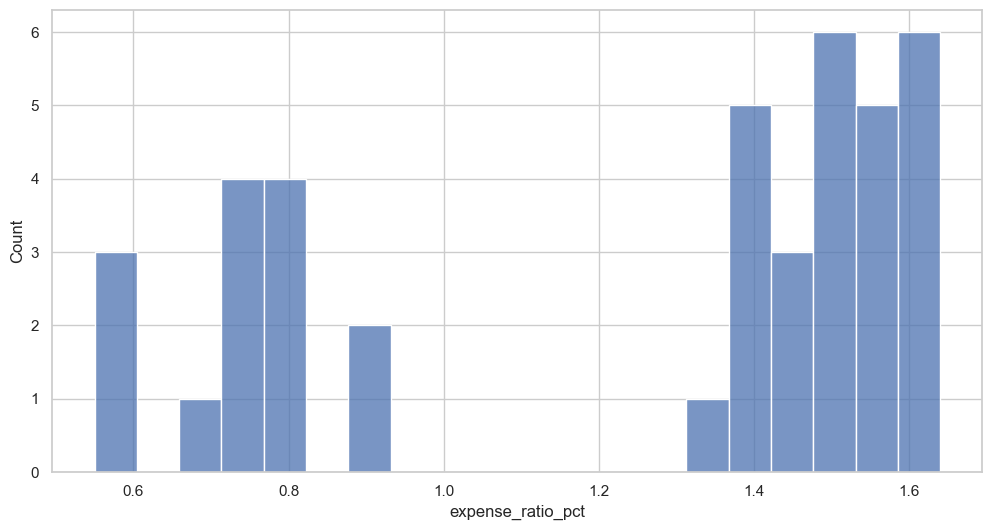

In [31]:
sns.histplot(
performance['expense_ratio_pct'],
bins=20
)
plt.savefig("../charts/expense_ratio_distribution.png")
plt.show()

Chart 15 Sharpe Ratio vs Return

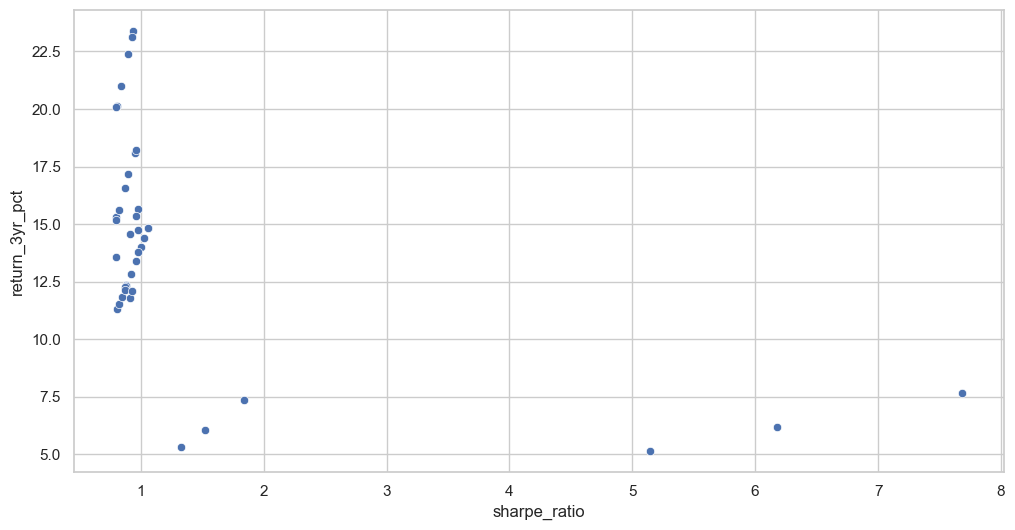

In [32]:
sns.scatterplot(
data=performance,
x='sharpe_ratio',
y='return_3yr_pct'
)
plt.savefig("../charts/sharpe_ratio_vs_return.png")
plt.show()